In [1]:
import torch
import torchvision
import torchvision.transforms as transforms


import numpy as np

import torch.optim as optim
from sympy.codegen.ast import none
from torch.utils.data import dataloader

from torch.utils.data import random_split, DataLoader

import threading

from agents.Classe_agent import Agent
from metrics import metrics_plot
from topologies.NetworkTopology import NetworkTopology

from models.model import Net,AlexNet

from training.plot_benchmark_results import plot_all_benchmark_metrics
from training.plot_benchmark_results import print_benchmark_summary

from metrics.metrics import plot_average_distance, node_weight_metric

from metrics.metrics import plot_cumulative_times ,plot_all_agent_node_weight_metric,plot_distance_heatmap,plot_cosine_similarity,plot_epoch_times

from metrics.Classe_model_metrics import ModelMetrics
#from metrics.plot_benchmark import*
from synchronize_weight import*
from training.scrpit_generate_agent import generate_agent
from training.scrpit_train_agent_sequential import benchmark_sequential
from hyperparametres import *
from ExperimentRunner import ExperimentRunner


In [2]:
# --- hyperparamètres ---

RANDOM_SEED = 123
BATCH_SIZE = 10
NUM_EPOCHES = 100

MOMENTUM = 0.9
LEARING_RATE = 0.001
SCALE = 0.1
IMG_SIZE = (128, 128)
LATENT_DIM = 10
N_AGENT = 10
k = 5
# Device configuration
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

torch.version
torch.version.cuda
torch.cuda.is_available()

agent_list = generate_agent(BATCH_SIZE,N_AGENT,DEVICE)



C:\Users\flofl\PycharmProjects\IA_A_à_Z\.venv\Lib\site-packages\torchvision\datasets\cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


0
Train size: 50000, Splits: [5555, 5555, 5555, 5555, 5555, 5555, 5555, 5555, 5555, 5555], Sum: 55550


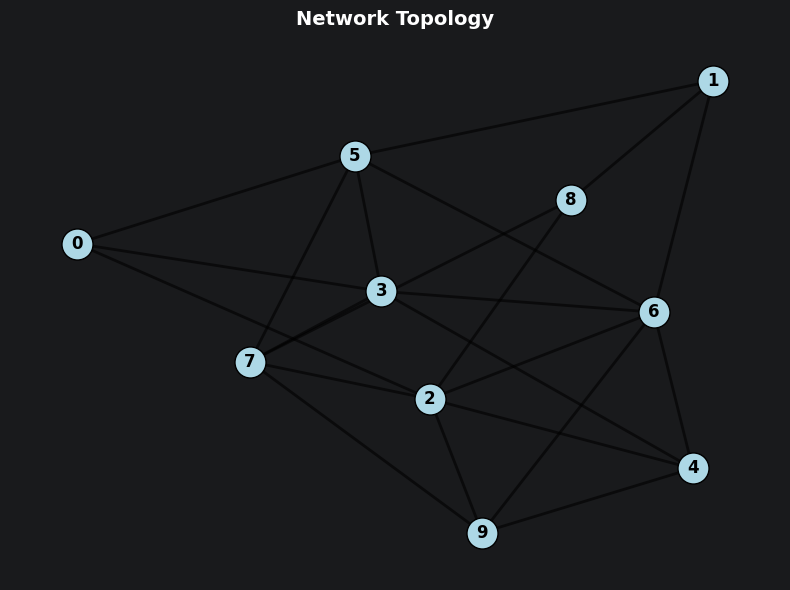

In [3]:

random_graph = NetworkTopology.random_graph(len(agent_list))

NetworkTopology.visualize_graph(random_graph)

In [11]:

def Consensus_step_fully_connected_graph(agent_list, graph, k, epoch, num_epochs,comm_cost=None):
    graph = NetworkTopology.fully_connected_graph(len(agent_list))
    Average_consensus_algorithm(agent_list, graph, comm_cost=comm_cost)

def Consensus_step_cycle_graph(agent_list, graph, k, epoch, num_epochs,comm_cost=None):
    graph = NetworkTopology.cycle_graph(len(agent_list))
    Average_consensus_algorithm(agent_list, graph, comm_cost=comm_cost)

def Consensus_step_star_graph(agent_list, graph, k, epoch, num_epochs,comm_cost=None):
    graph = NetworkTopology.star_graph(len(agent_list))
    Average_consensus_algorithm(agent_list, graph, comm_cost=comm_cost)

def Consensus_step_random_graph(agent_list, graph, k, epoch, num_epochs,comm_cost=None):

    Average_consensus_algorithm(agent_list, graph, comm_cost=comm_cost)

# ──────────────────────────────────────────────────────────────
# Dictionnaire des méthodes à comparer
# ──────────────────────────────────────────────────────────────

COMMUNICATION_METHODS = {
    f"AC_fully_connected_graph" : Consensus_step_fully_connected_graph,
    f"AC_cycle_graph)"          : Consensus_step_cycle_graph,
    f"AC_star_graph"            : Consensus_step_star_graph,
    f"AC_random_graph"          : Consensus_step_random_graph
}

results,comparator = benchmark_sequential(
    communication_methods=COMMUNICATION_METHODS,
    num_epochs=NUM_EPOCHES,
    graph=random_graph,
    k=k,
    BATCH_SIZE=BATCH_SIZE,
    N_AGENT=N_AGENT,
    DEVICE=DEVICE,
)



  RUN — méthode : AC_fully_connected_graph
0
Train size: 50000, Splits: [5555, 5555, 5555, 5555, 5555, 5555, 5555, 5555, 5555, 5555], Sum: 55550
  [Epoch 1/100] threads started …
Agent 9 start
Agent 2 start
Agent 7 start
Agent 8 start
Agent 1 start
Agent 0 start
Agent 6 start
Agent 3 start
Agent 4 start
Agent 5 start
Model9 - Acc:9.88 % - Loss:2.3025542607307434 %
Model2 - Acc:10.66 % - Loss:2.302592866420746 %
Model8 - Acc:10.54 % - Loss:2.3034979372024535 %
Model1 - Acc:11.66 % - Loss:2.3032801351547243 %
Model0 - Acc:14.16 % - Loss:2.3023618202209475 %
Model7 - Acc:11.0 % - Loss:2.2999647526741027 %
Model6 - Acc:10.26 % - Loss:2.3023224482536317 %
Model3 - Acc:9.96 % - Loss:2.3025421228408813 %
Model4 - Acc:9.5 % - Loss:2.3033802971839905 %
Model5 - Acc:10.82 % - Loss:2.301241277217865 %
[DEBUG] set_epoch_messages called → 90 messages
[DEBUG] _resolve_n_messages → _epoch_n_messages = 90
[DEBUG] _record epoch=0 → n_messages=90
  [Epoch 1/100] ✓  time=36.22s  cumulative=36.22s
  [Epo

Exception ignored while calling deallocator <function _MultiProcessingDataLoaderIter.__del__ at 0x0000014CE1DFA4B0>:
Traceback (most recent call last):
  File "C:\Users\flofl\PycharmProjects\IA_A_à_Z\.venv\Lib\site-packages\torch\utils\data\dataloader.py", line 1709, in __del__
    self._shutdown_workers()
  File "C:\Users\flofl\PycharmProjects\IA_A_à_Z\.venv\Lib\site-packages\torch\utils\data\dataloader.py", line 1667, in _shutdown_workers
    if self._persistent_workers or self._workers_status[worker_id]:
AttributeError: '_MultiProcessingDataLoaderIter' object has no attribute '_workers_status'


Erreur agent 7 : [Errno 22] Invalid argument
Agent 0 start
Agent 1 start
Agent 8 start
Agent 9 start
Agent 6 start
Agent 2 start
Agent 4 start
Agent 5 start
Agent 3 start
Model0 - Acc:10.36 % - Loss:2.3026571383476258 %
Model1 - Acc:9.92 % - Loss:2.302486632347107 %
Model8 - Acc:10.72 % - Loss:2.302319952964783 %
Model9 - Acc:10.18 % - Loss:2.302281108856201 %
Model6 - Acc:9.64 % - Loss:2.302256071090698 %
Model2 - Acc:10.36 % - Loss:2.3025732913017274 %
Model4 - Acc:10.36 % - Loss:2.3022721095085146 %
Model5 - Acc:10.24 % - Loss:2.3027109503746033 %
Model3 - Acc:10.04 % - Loss:2.302425359249115 %
[DEBUG] set_epoch_messages called → 20 messages
[DEBUG] _resolve_n_messages → _epoch_n_messages = 20
[DEBUG] _record epoch=24 → n_messages=20
  [Epoch 25/100] ✓  time=32.02s  cumulative=815.89s
  [Epoch 26/100] threads started …
Agent 4 start
Agent 3 start
Agent 5 start
Agent 6 start
Agent 9 start
Agent 8 start
Agent 7 start
Agent 2 start
Agent 0 start
Agent 1 start
Model4 - Acc:10.16 % - Los

Exception ignored while calling deallocator <function _MultiProcessingDataLoaderIter.__del__ at 0x0000014CE1DFA4B0>:
Traceback (most recent call last):
  File "C:\Users\flofl\PycharmProjects\IA_A_à_Z\.venv\Lib\site-packages\torch\utils\data\dataloader.py", line 1709, in __del__
    self._shutdown_workers()
  File "C:\Users\flofl\PycharmProjects\IA_A_à_Z\.venv\Lib\site-packages\torch\utils\data\dataloader.py", line 1667, in _shutdown_workers
    if self._persistent_workers or self._workers_status[worker_id]:
AttributeError: '_MultiProcessingDataLoaderIter' object has no attribute '_workers_status'


Erreur agent 9 : [Errno 22] Invalid argument
Agent 7 start
Agent 8 start
Agent 6 start
Agent 4 start
Agent 5 start
Agent 0 start
Agent 1 start
Agent 2 start
Agent 3 start
Model7 - Acc:10.7 % - Loss:2.3021177196502687 %
Model8 - Acc:9.76 % - Loss:2.3028514823913575 %
Model6 - Acc:10.1 % - Loss:2.302097568035126 %
Model4 - Acc:10.6 % - Loss:2.3023950715065 %
Model0 - Acc:10.62 % - Loss:2.3025434165000918 %
Model2 - Acc:10.04 % - Loss:2.3025055589675905 %
Model1 - Acc:10.12 % - Loss:2.3024271054267884 %
Model3 - Acc:10.54 % - Loss:2.302304132938385 %
Model5 - Acc:10.32 % - Loss:2.3027280235290526 %
[DEBUG] set_epoch_messages called → 18 messages
[DEBUG] _resolve_n_messages → _epoch_n_messages = 18
[DEBUG] _record epoch=7 → n_messages=18
  [Epoch 8/100] ✓  time=31.51s  cumulative=272.87s
  [Epoch 9/100] threads started …
Agent 3 start
Agent 4 start
Agent 1 start
Agent 2 start
Agent 9 start
Agent 8 start
Agent 0 start
Agent 6 start
Agent 7 start
Agent 5 start
Model3 - Acc:10.54 % - Loss:2.3

...

Erreur agent 9 : [Errno 22] Invalid argument
Agent 4 start
Agent 3 start
Agent 2 start
Agent 0 start
Agent 5 start
Agent 6 start
Agent 7 start
Agent 8 start
Agent 1 start
Model4 - Acc:32.68 % - Loss:1.7691023602485656 %
Model3 - Acc:32.54 % - Loss:1.7437213742733002 %
Model0 - Acc:33.74 % - Loss:1.7311425669193268 %
Model5 - Acc:33.44 % - Loss:1.7292867176532745 %
Model6 - Acc:32.46 % - Loss:1.7405913031101228 %
Model2 - Acc:32.48 % - Loss:1.7564915030002595 %
Model7 - Acc:31.94 % - Loss:1.7546135623455048 %
Model8 - Acc:33.44 % - Loss:1.7284696712493897 %
Model1 - Acc:33.46 % - Loss:1.7419503121376037 %
[DEBUG] set_epoch_messages called → 42 messages
[DEBUG] _resolve_n_messages → _epoch_n_messages = 42
[DEBUG] _record epoch=35 → n_messages=42
  [Epoch 36/100] ✓  time=29.76s  cumulative=1241.21s
  [Epoch 37/100] threads started …
Agent 8 start
Agent 7 start
Agent 9 start
Agent 1 start
Agent 3 start
Agent 6 start
Agent 0 start
Agent 4 start
Agent 5 start
Agent 2 start
Model8 - Acc:34.16

Exception ignored while calling deallocator <function _MultiProcessingDataLoaderIter.__del__ at 0x0000014CE1DFA4B0>:
Traceback (most recent call last):
  File "C:\Users\flofl\PycharmProjects\IA_A_à_Z\.venv\Lib\site-packages\torch\utils\data\dataloader.py", line 1709, in __del__
    self._shutdown_workers()
  File "C:\Users\flofl\PycharmProjects\IA_A_à_Z\.venv\Lib\site-packages\torch\utils\data\dataloader.py", line 1667, in _shutdown_workers
    if self._persistent_workers or self._workers_status[worker_id]:
AttributeError: '_MultiProcessingDataLoaderIter' object has no attribute '_workers_status'


Erreur agent 3 : [Errno 22] Invalid argument
Agent 1 start
Agent 9 start
Agent 2 start
Agent 4 start
Agent 0 start
Agent 8 start
Agent 5 start
Agent 7 start
Agent 6 start
Model1 - Acc:50.38 % - Loss:1.3525859088897705 %
Model2 - Acc:50.58 % - Loss:1.3561355974674225 %
Model9 - Acc:49.7 % - Loss:1.3549653315544128 %
Model4 - Acc:50.04 % - Loss:1.3720603259801865 %
Model0 - Acc:50.78 % - Loss:1.3378164393305778 %
Model8 - Acc:50.74 % - Loss:1.3479623458385468 %
Model7 - Acc:52.02 % - Loss:1.3486737447381019 %
Model5 - Acc:51.34 % - Loss:1.3442458214759827 %
Model6 - Acc:50.52 % - Loss:1.3628562012910843 %
[DEBUG] set_epoch_messages called → 42 messages
[DEBUG] _resolve_n_messages → _epoch_n_messages = 42
[DEBUG] _record epoch=54 → n_messages=42
  [Epoch 55/100] ✓  time=30.14s  cumulative=1864.59s
  [Epoch 56/100] threads started …
Agent 8 start
Agent 5 start
Agent 6 start
Agent 0 start
Agent 7 start
Agent 3 start
Agent 2 start
Agent 4 start
Agent 9 start
Agent 1 start
Model8 - Acc:51.44 

Exception ignored while calling deallocator <function _MultiProcessingDataLoaderIter.__del__ at 0x0000014CE1DFA4B0>:
Traceback (most recent call last):
  File "C:\Users\flofl\PycharmProjects\IA_A_à_Z\.venv\Lib\site-packages\torch\utils\data\dataloader.py", line 1709, in __del__
    self._shutdown_workers()
  File "C:\Users\flofl\PycharmProjects\IA_A_à_Z\.venv\Lib\site-packages\torch\utils\data\dataloader.py", line 1667, in _shutdown_workers
    if self._persistent_workers or self._workers_status[worker_id]:
AttributeError: '_MultiProcessingDataLoaderIter' object has no attribute '_workers_status'


Erreur agent 0 : [Errno 22] Invalid argument
Agent 3 start
Agent 4 start
Agent 5 start
Agent 9 start
Agent 1 start
Agent 8 start
Agent 2 start
Agent 7 start
Agent 6 start
Model3 - Acc:61.48 % - Loss:1.09103909689188 %
Model4 - Acc:59.62 % - Loss:1.1299931917786599 %
Model5 - Acc:60.82 % - Loss:1.1088368601202965 %
Model9 - Acc:60.1 % - Loss:1.1104026346802711 %
Model1 - Acc:60.44 % - Loss:1.0982532312870026 %
Model8 - Acc:61.12 % - Loss:1.0850316304564476 %
Model7 - Acc:61.16 % - Loss:1.0873055723309517 %
Model6 - Acc:61.64 % - Loss:1.0715211655199528 %
Model2 - Acc:59.42 % - Loss:1.122233230650425 %
[DEBUG] set_epoch_messages called → 42 messages
[DEBUG] _resolve_n_messages → _epoch_n_messages = 42
[DEBUG] _record epoch=78 → n_messages=42
  [Epoch 79/100] ✓  time=30.03s  cumulative=2686.50s
  [Epoch 80/100] threads started …
Agent 9 start
Agent 7 start
Agent 8 start
Agent 0 start
Agent 6 start
Agent 1 start
Agent 5 start
Agent 4 start
Agent 3 start
Agent 2 start
Model9 - Acc:60.12 % -

In [12]:
comparator.rank()


══════════════════════════════════════════════════════════════════════
  CLASSEMENT DES MÉTHODES PAR EFFICACITÉ (accuracy / MB)
──────────────────────────────────────────────────────────────────────
  Rang  Méthode                   Total MB     Synchro moy    Efficacité
──────────────────────────────────────────────────────────────────────
  1     AC_fully_connected_graph  2128.807     23.30          N/A
  2     AC_cycle_graph)           473.068      11.20          N/A
  3     AC_star_graph             425.761      10.53          N/A
  4     AC_random_graph           993.443      14.51          N/A
══════════════════════════════════════════════════════════════════════



[('AC_fully_connected_graph', 2128.8070678710938, 23.302312011364847, 0.0),
 ('AC_cycle_graph)', 473.0682373046875, 11.198418005369604, 0.0),
 ('AC_star_graph', 425.76141357421875, 10.534480994101614, 0.0),
 ('AC_random_graph', 993.4432983398438, 14.512718024197966, 0.0)]

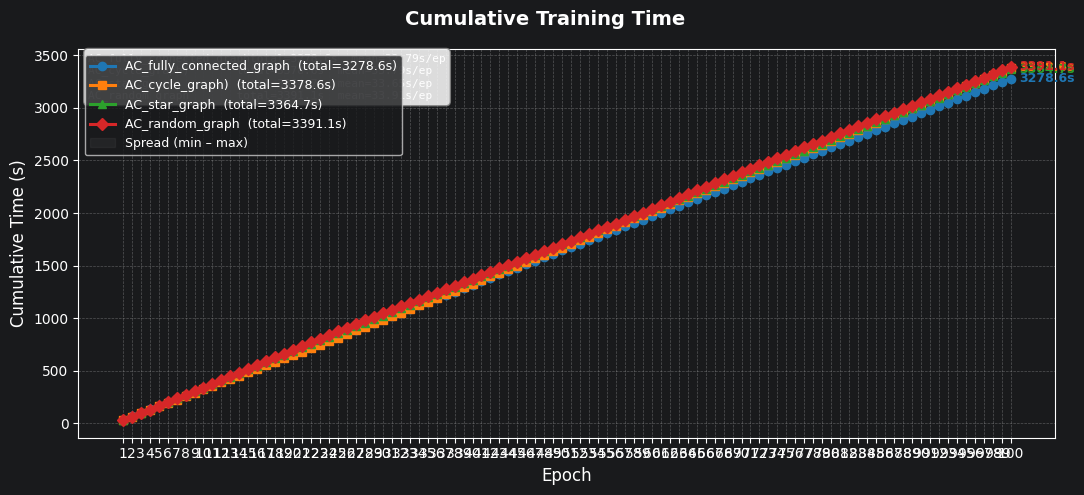

In [13]:
plot_cumulative_times(results)

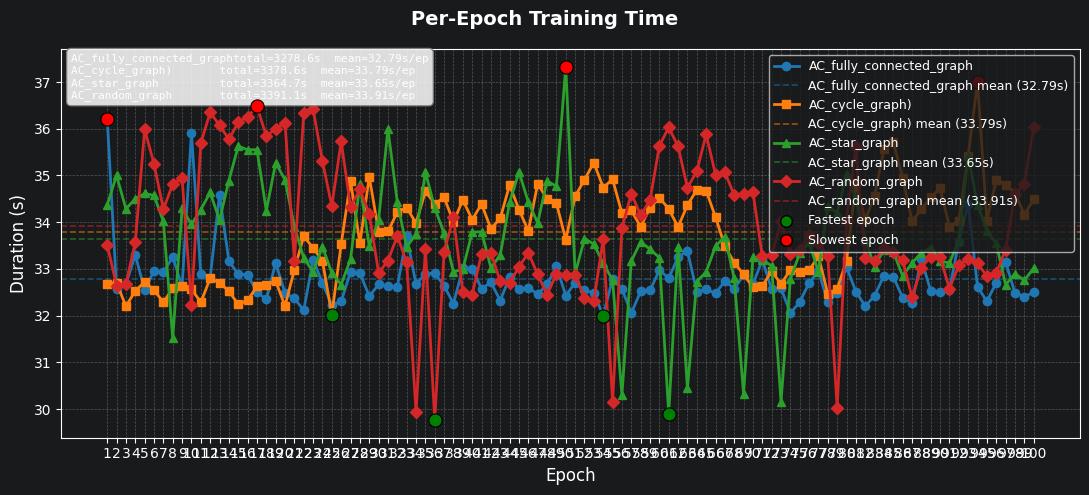

In [14]:
plot_epoch_times(results)

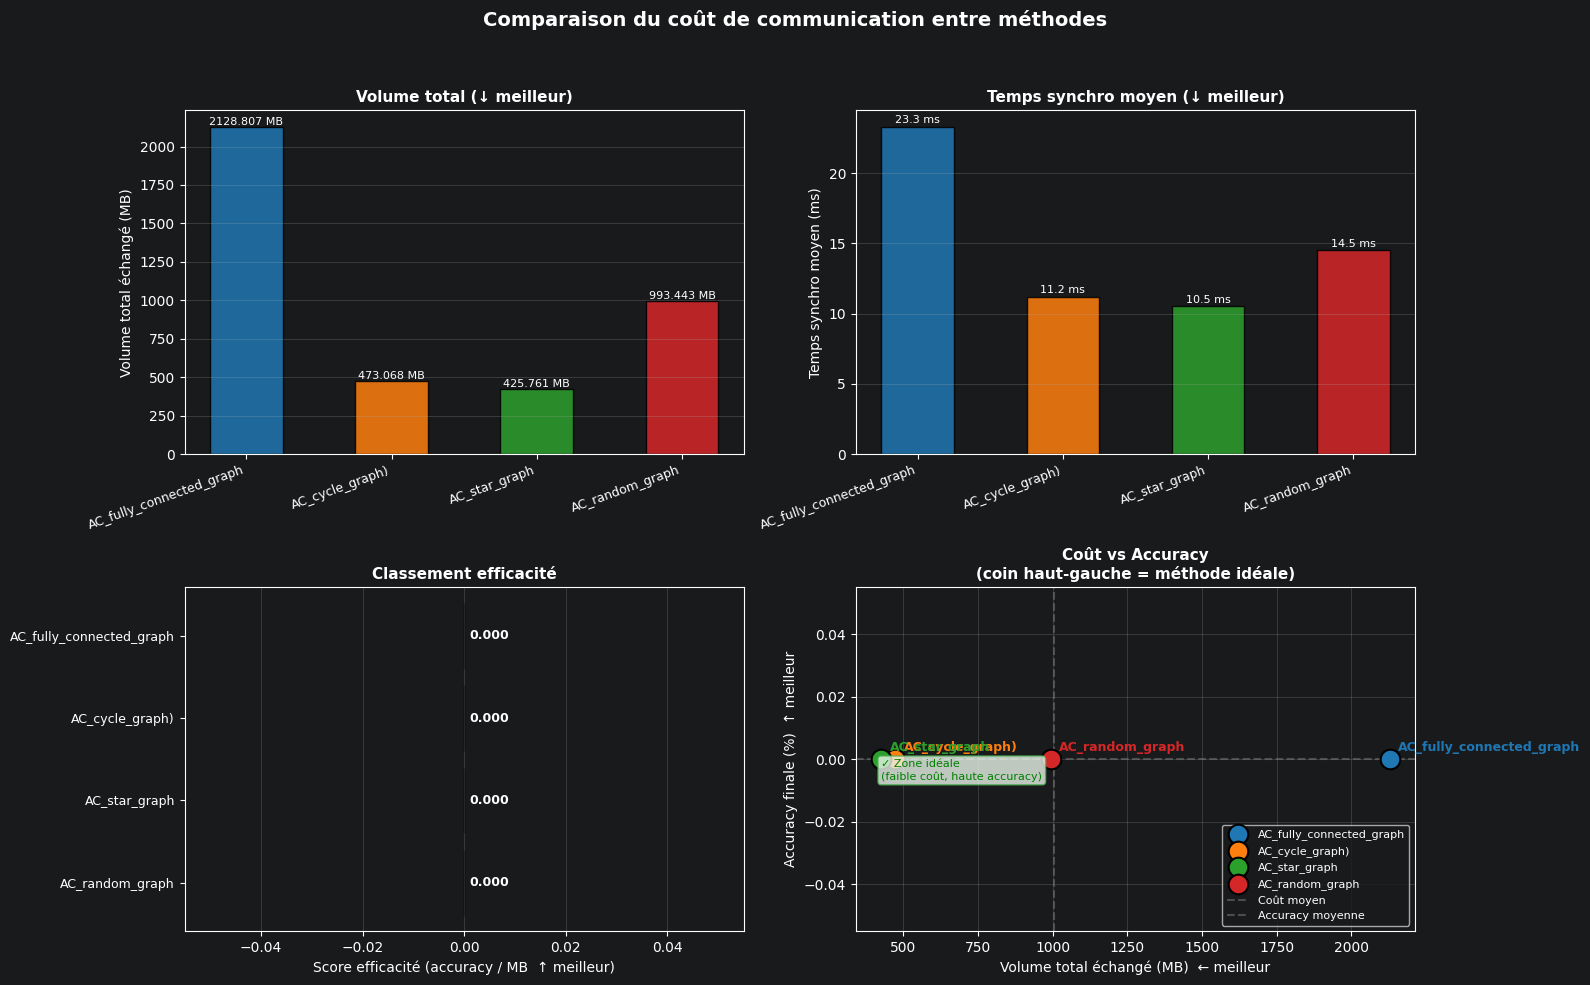

In [15]:
comparator.plot_comparison()

In [16]:
for result in results:
    print(f"\n── {result.method_name} ──")
    result.comm_cost.summary()


── AC_fully_connected_graph ──

══════════════════════════════════════════════════════════
  CommunicationCostMetric — AC_fully_connected_graph
──────────────────────────────────────────────────────────
  Agents              : 10
  Paramètres/modèle   : 62,006
  Époques mesurées    : 100
──────────────────────────────────────────────────────────
  VOLUME
    Octets/message    : 242.2 KB
    Total échangé     : 2128.807 MB
    Total messages    : 9,000
──────────────────────────────────────────────────────────
  TEMPS
    Synchro moy./ép.  : 23.30 ms
    Synchro totale    : 2330.2 ms
──────────────────────────────────────────────────────────
  EFFICACITÉ
    Accuracy finale   : N/A
    Score efficacité  : N/A
    Coût/point acc.   : N/A
══════════════════════════════════════════════════════════


── AC_cycle_graph) ──

══════════════════════════════════════════════════════════
  CommunicationCostMetric — AC_cycle_graph)
──────────────────────────────────────────────────────────
  Agent

In [17]:
print_benchmark_summary(results)


Méthode                          Val Loss    Val Acc  Train Acc
AC_fully_connected_graph           1.0911     61.74%     60.84%
AC_cycle_graph)                    1.1587     59.28%     64.26%
AC_star_graph                      1.1557     61.83%     90.66%
AC_random_graph                    1.0661     62.73%     68.82%


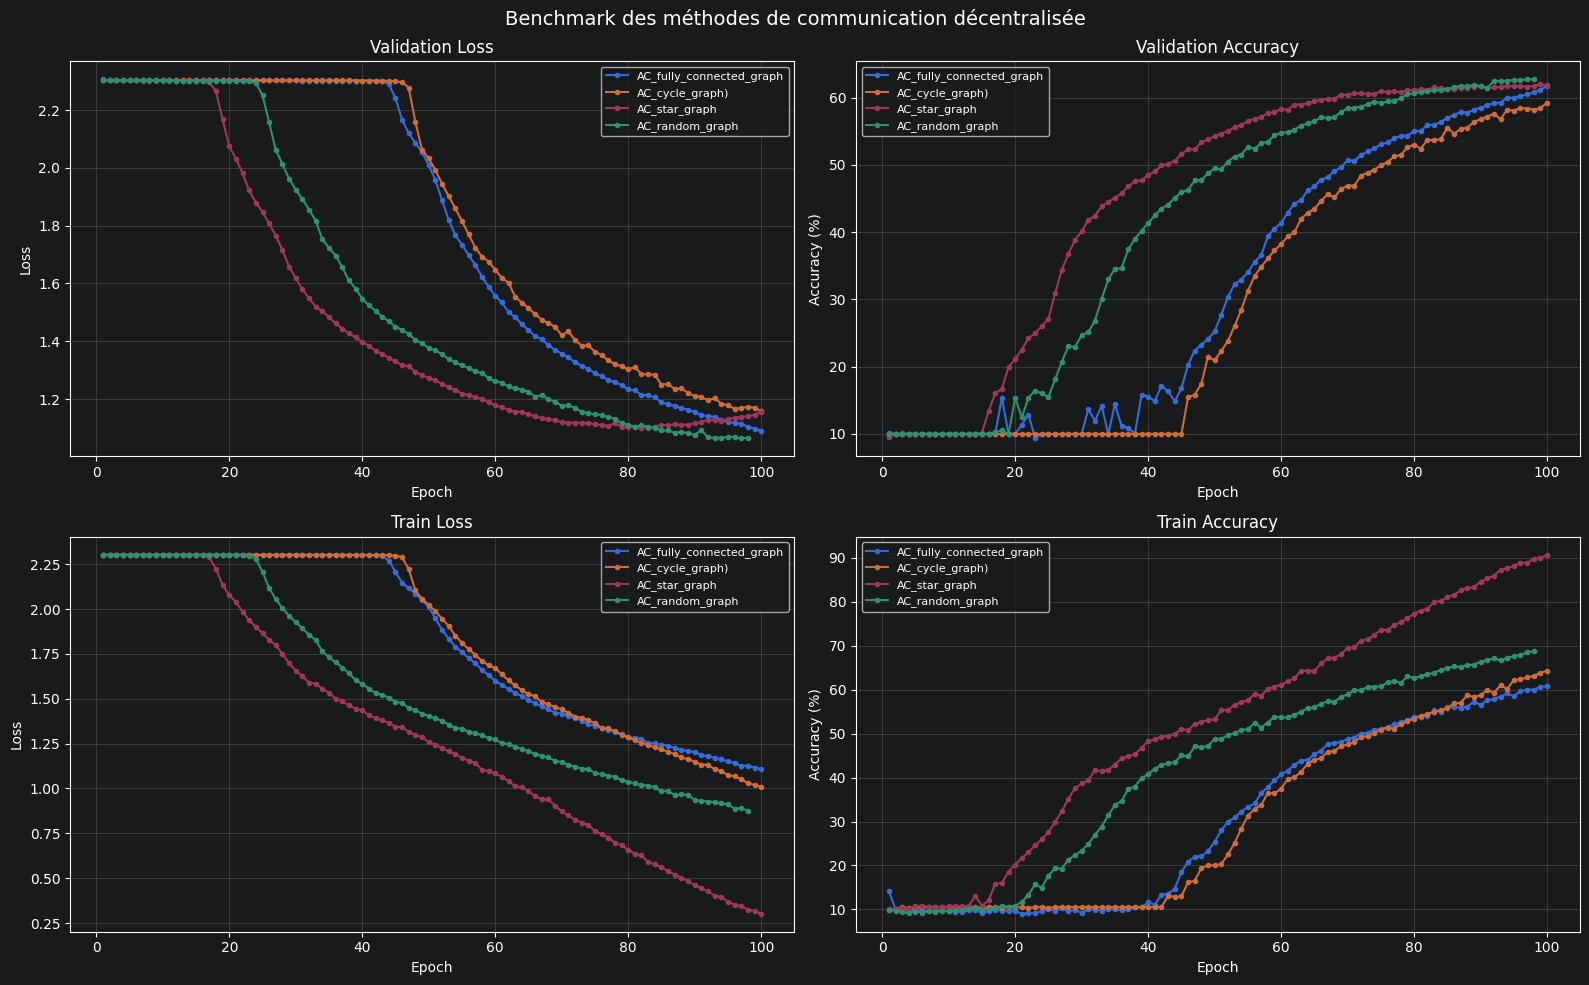

In [18]:
plot_all_benchmark_metrics(results)

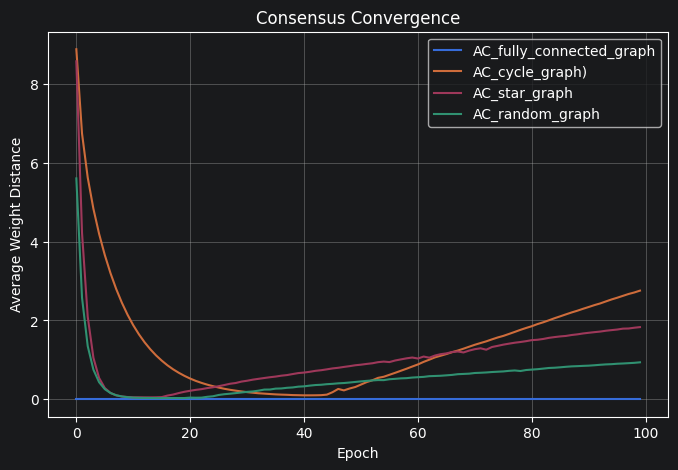

In [19]:
plot_average_distance(results)
#plot_average_distance(agent_list)


═══════════════════════════════════════════════════════
  RunResult : AC_fully_connected_graph
───────────────────────────────────────────────────────
  Accuracy  finale : 61.74%
  Val Loss  finale : 1.0911
  Temps total      : 3278.61s
  Temps moyen/ép.  : 32.79s
  Époque la + rapide : ép.54 (32.00s)
  Époque la + lente  : ép.1 (36.22s)
═══════════════════════════════════════════════════════

══════════════════════════════════════════════════════════
  CommunicationCostMetric — AC_fully_connected_graph
──────────────────────────────────────────────────────────
  Agents              : 10
  Paramètres/modèle   : 62,006
  Époques mesurées    : 100
──────────────────────────────────────────────────────────
  VOLUME
    Octets/message    : 242.2 KB
    Total échangé     : 2128.807 MB
    Total messages    : 9,000
──────────────────────────────────────────────────────────
  TEMPS
    Synchro moy./ép.  : 23.30 ms
    Synchro totale    : 2330.2 ms
────────────────────────────────────────────

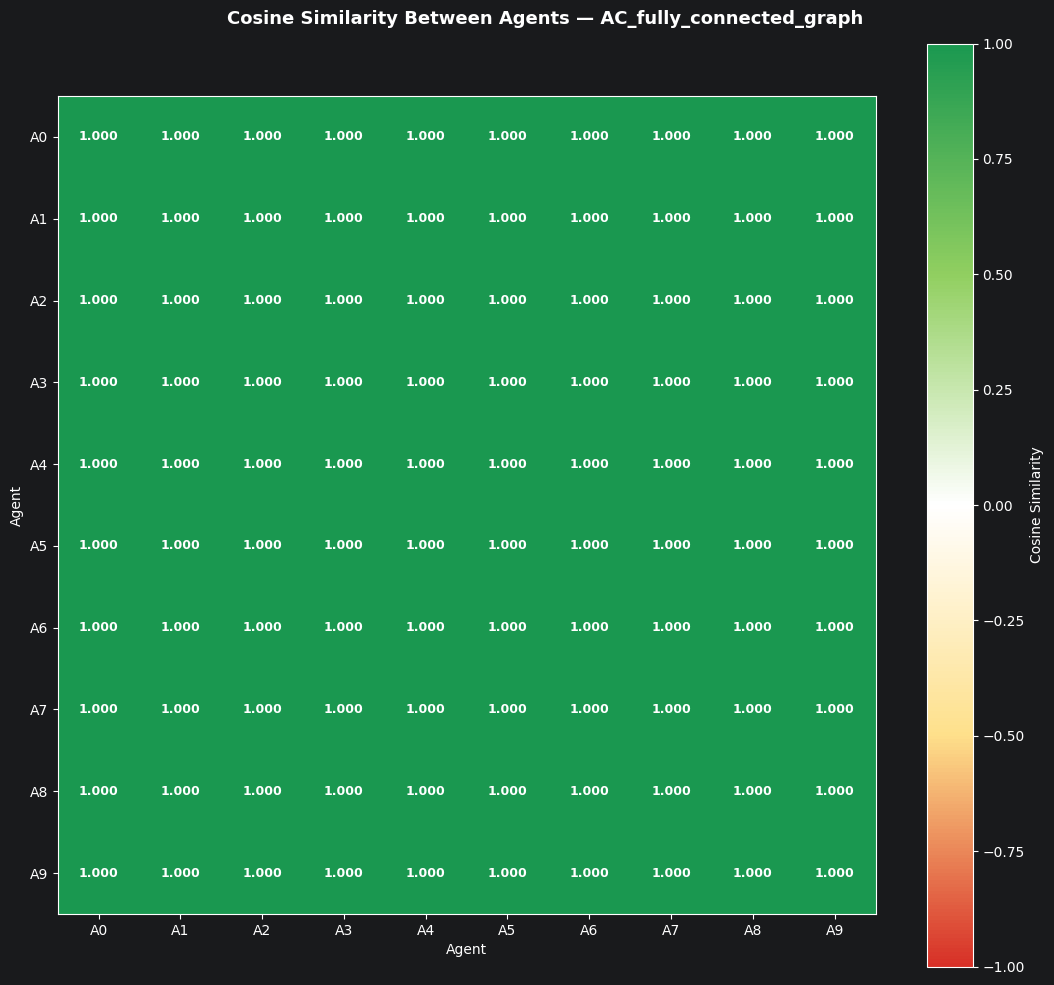

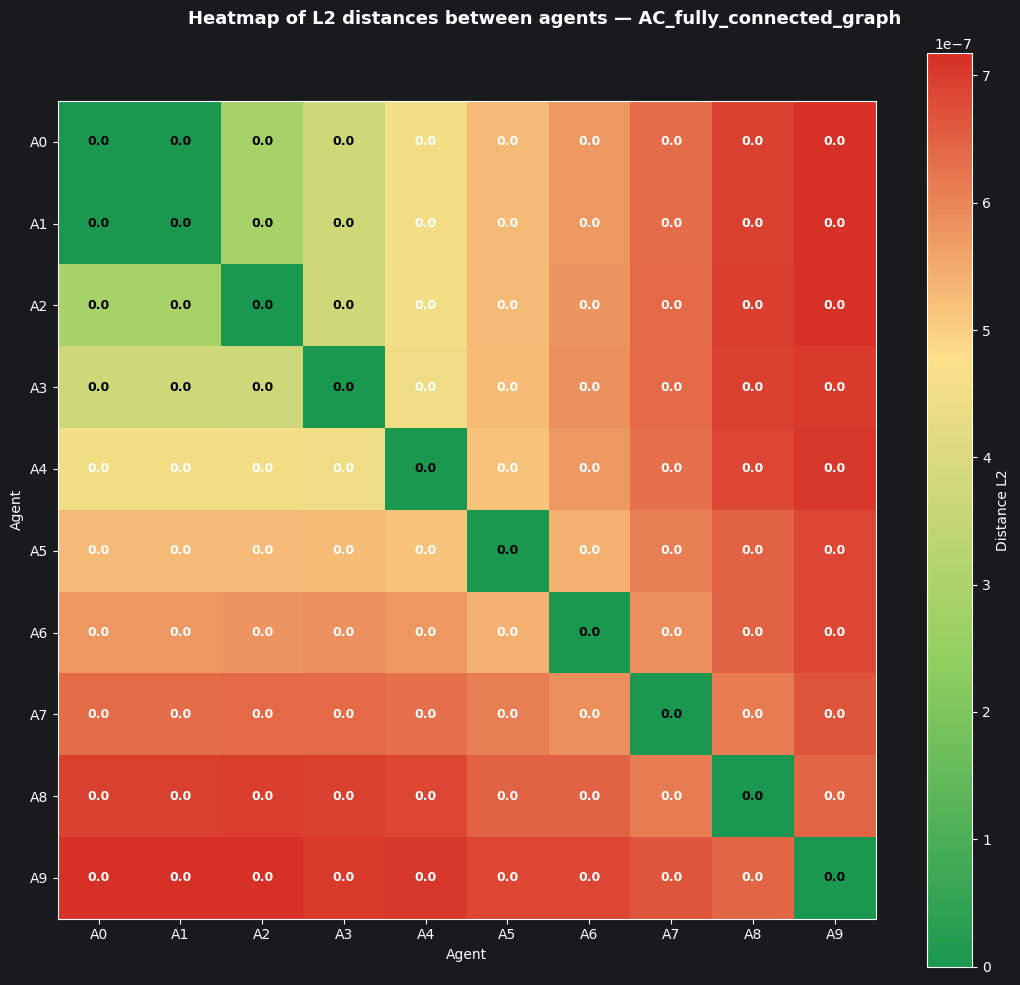

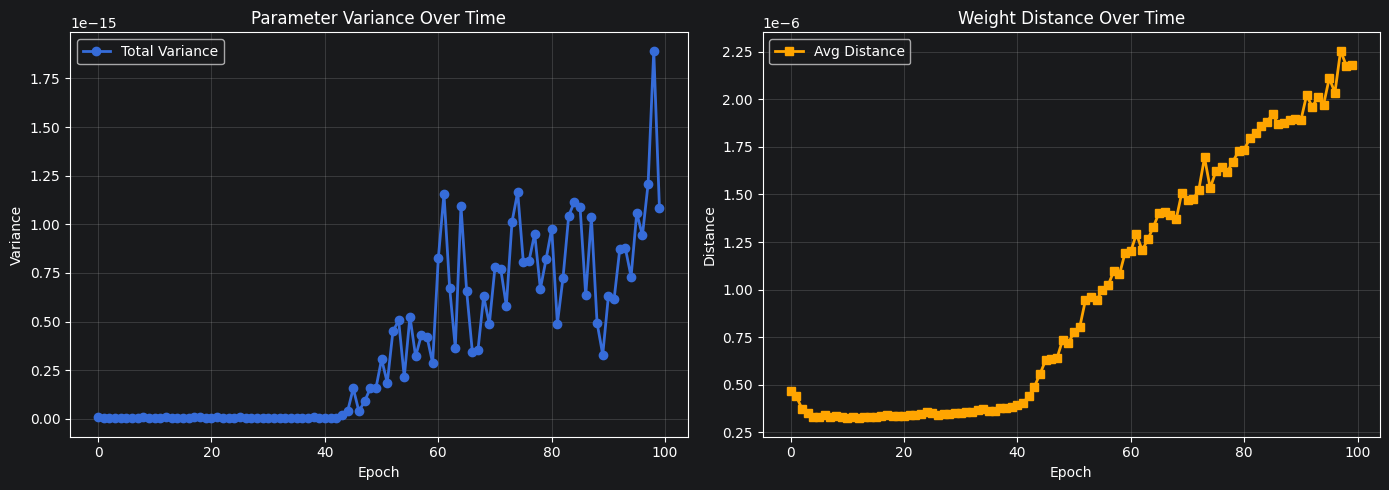


═══════════════════════════════════════════════════════
  RunResult : AC_cycle_graph)
───────────────────────────────────────────────────────
  Accuracy  finale : 59.28%
  Val Loss  finale : 1.1587
  Temps total      : 3378.56s
  Temps moyen/ép.  : 33.79s
  Époque la + rapide : ép.25 (32.02s)
  Époque la + lente  : ép.94 (37.01s)
═══════════════════════════════════════════════════════

══════════════════════════════════════════════════════════
  CommunicationCostMetric — AC_cycle_graph)
──────────────────────────────────────────────────────────
  Agents              : 10
  Paramètres/modèle   : 62,006
  Époques mesurées    : 100
──────────────────────────────────────────────────────────
  VOLUME
    Octets/message    : 242.2 KB
    Total échangé     : 473.068 MB
    Total messages    : 2,000
──────────────────────────────────────────────────────────
  TEMPS
    Synchro moy./ép.  : 11.20 ms
    Synchro totale    : 1119.8 ms
──────────────────────────────────────────────────────────
  E

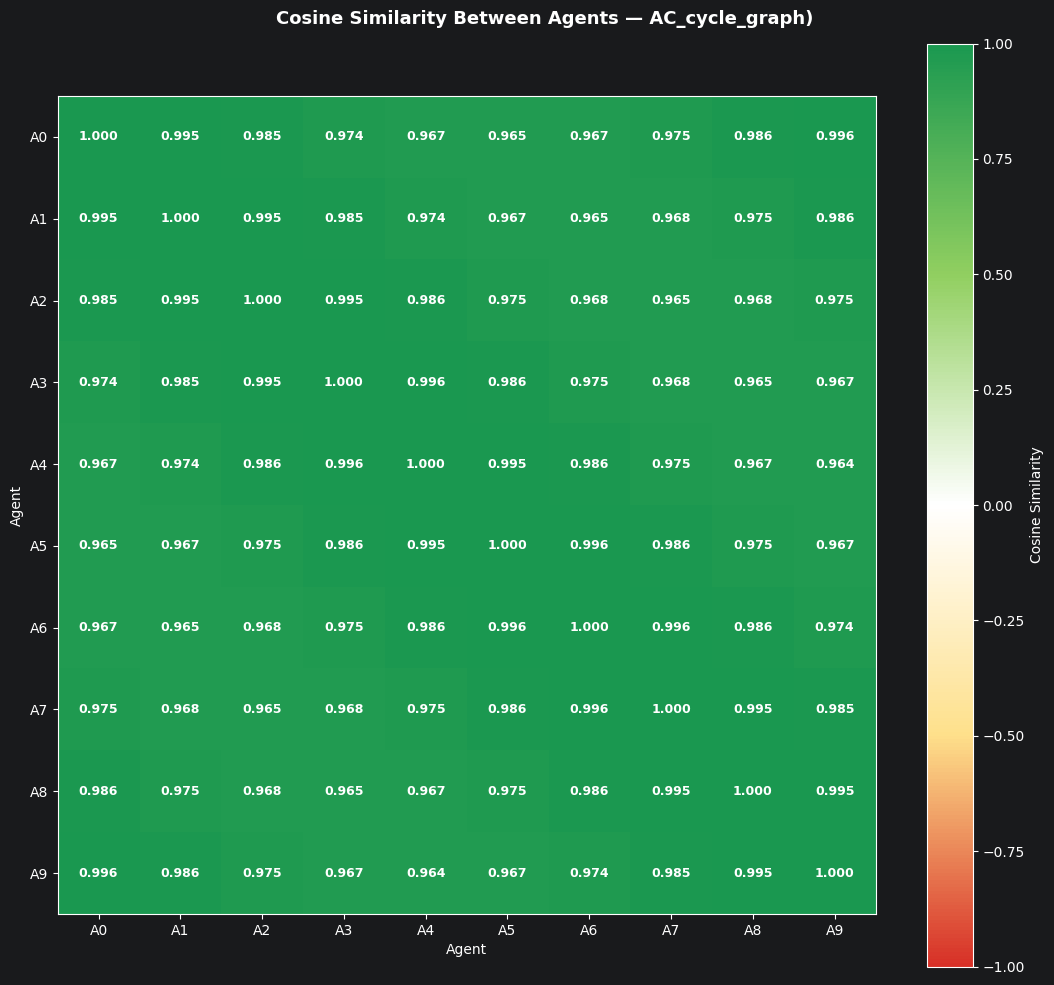

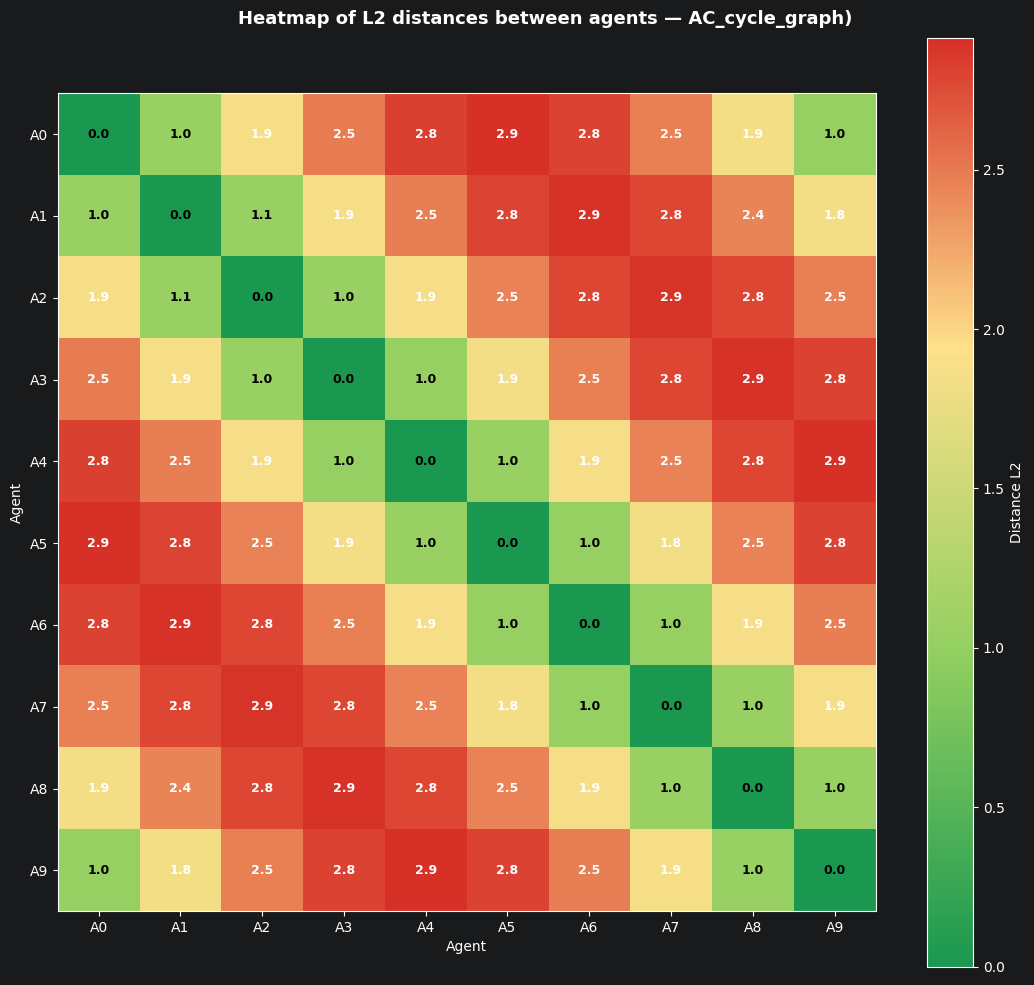

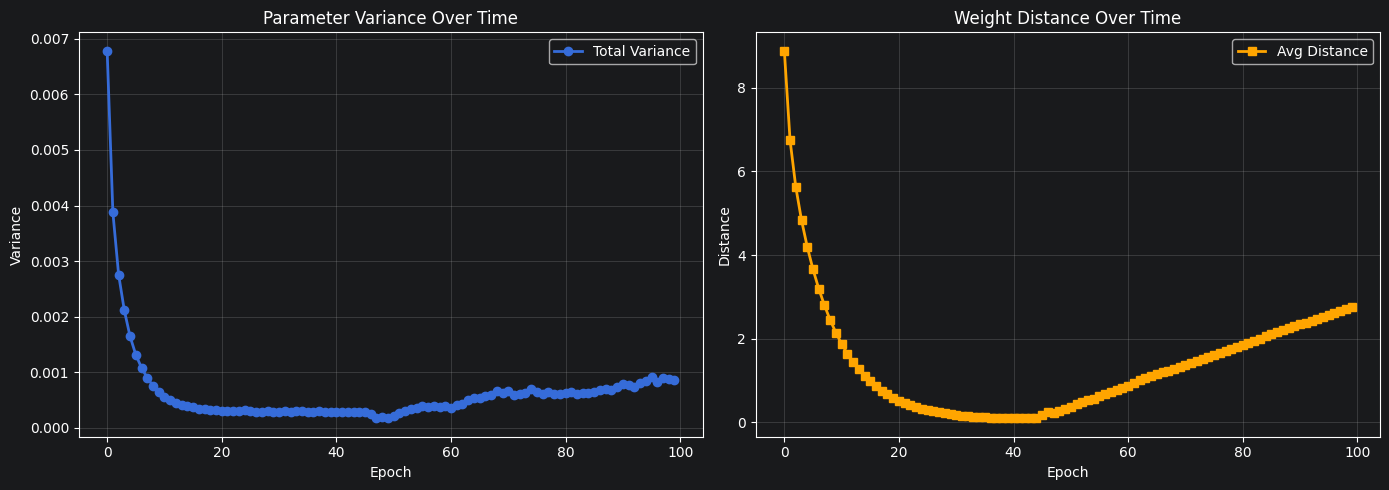


═══════════════════════════════════════════════════════
  RunResult : AC_star_graph
───────────────────────────────────────────────────────
  Accuracy  finale : 61.83%
  Val Loss  finale : 1.1557
  Temps total      : 3364.72s
  Temps moyen/ép.  : 33.65s
  Époque la + rapide : ép.61 (29.90s)
  Époque la + lente  : ép.50 (37.33s)
═══════════════════════════════════════════════════════

══════════════════════════════════════════════════════════
  CommunicationCostMetric — AC_star_graph
──────────────────────────────────────────────────────────
  Agents              : 10
  Paramètres/modèle   : 62,006
  Époques mesurées    : 100
──────────────────────────────────────────────────────────
  VOLUME
    Octets/message    : 242.2 KB
    Total échangé     : 425.761 MB
    Total messages    : 1,800
──────────────────────────────────────────────────────────
  TEMPS
    Synchro moy./ép.  : 10.53 ms
    Synchro totale    : 1053.4 ms
──────────────────────────────────────────────────────────
  EFFIC

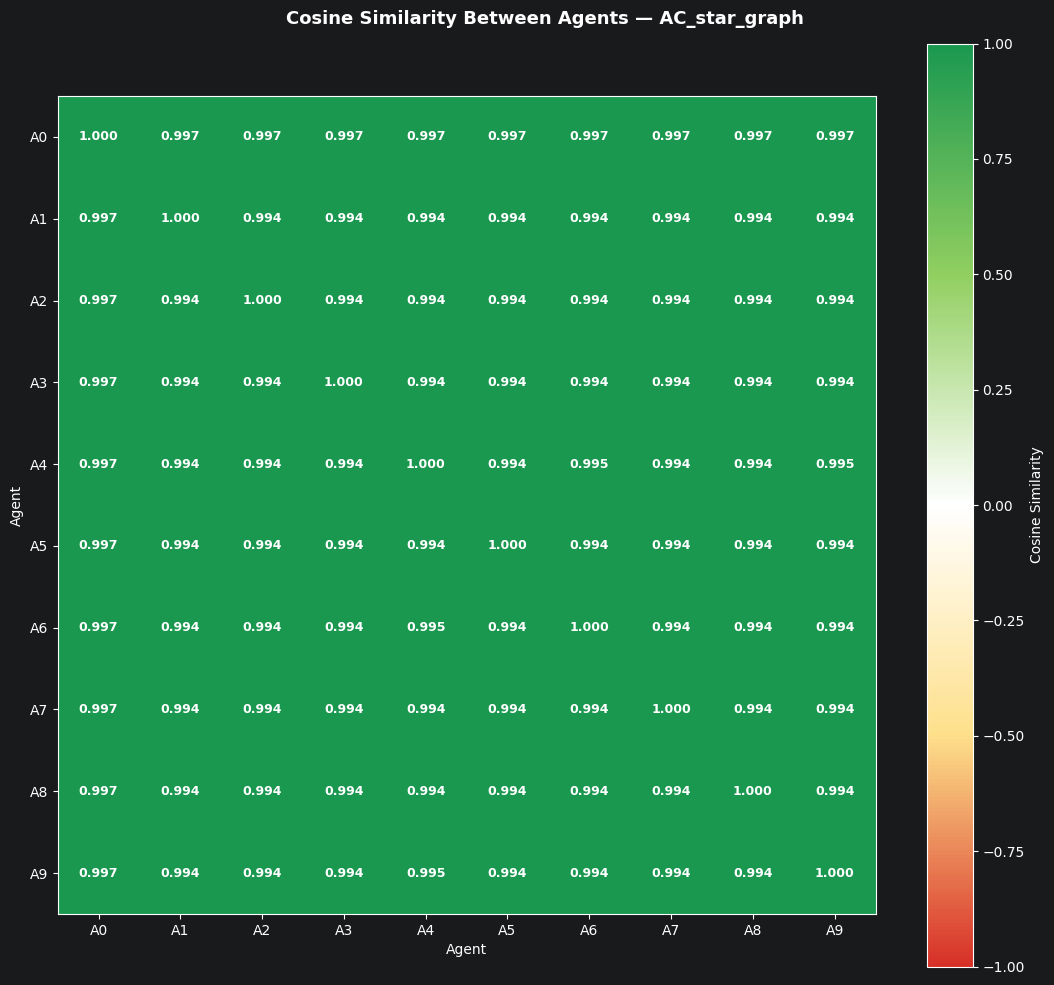

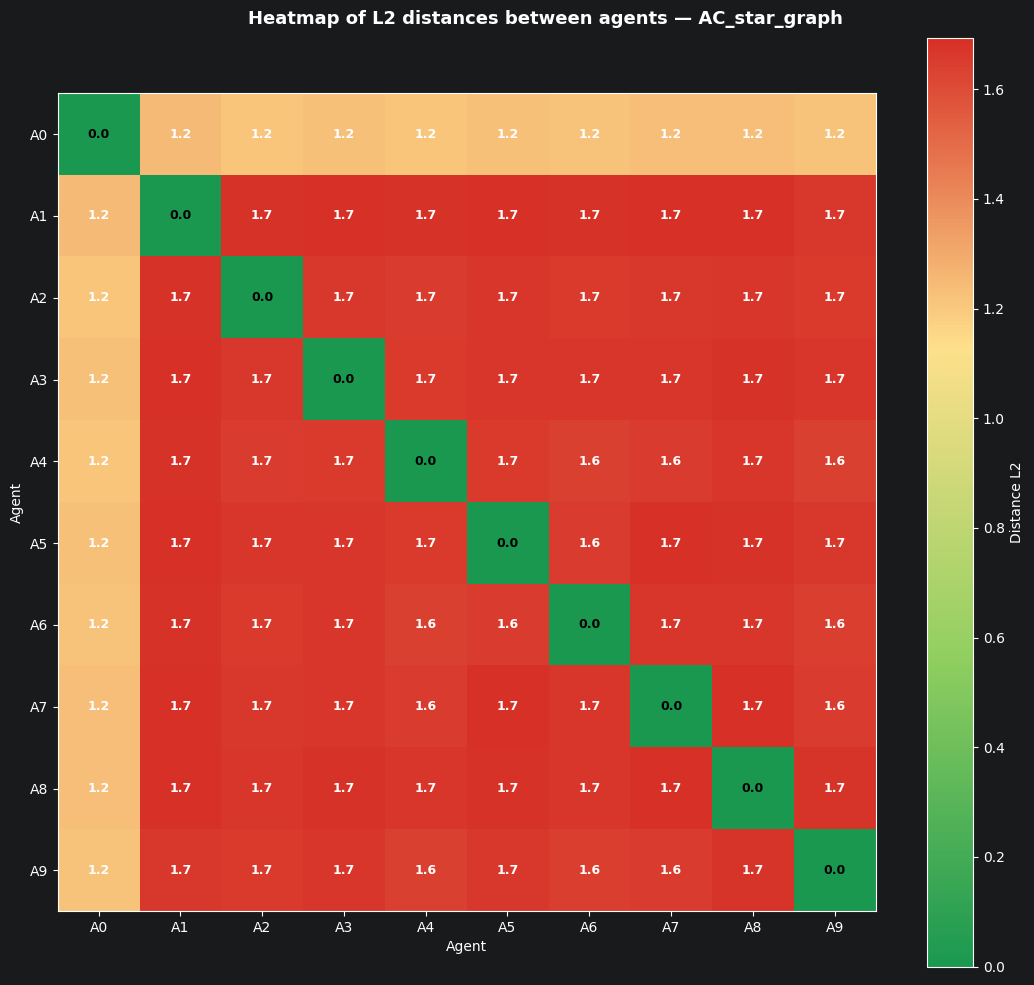

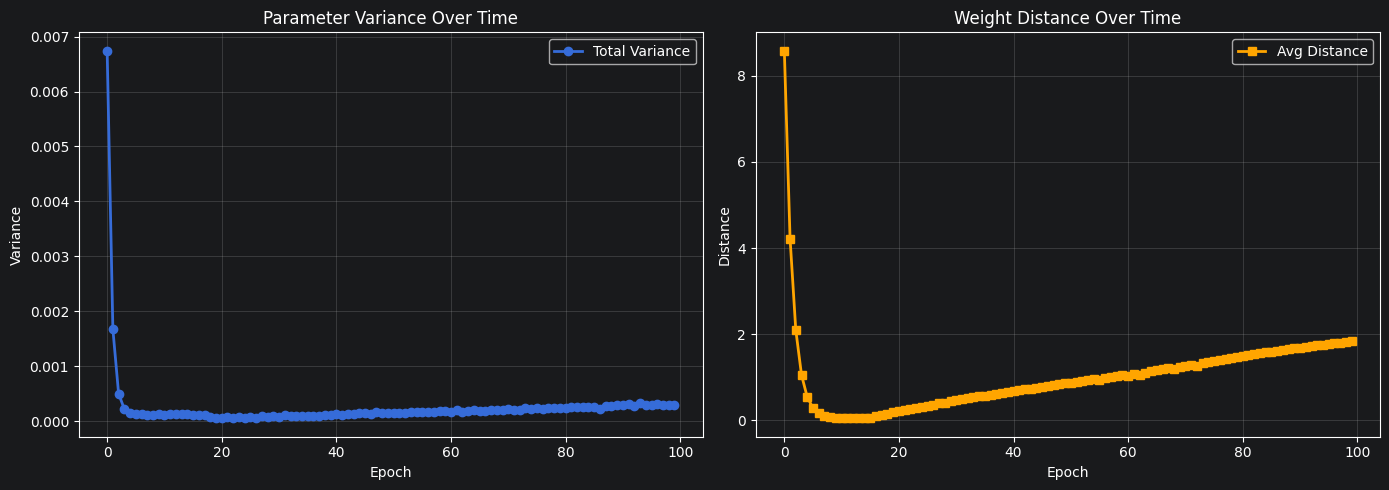


═══════════════════════════════════════════════════════
  RunResult : AC_random_graph
───────────────────────────────────────────────────────
  Accuracy  finale : 62.73%
  Val Loss  finale : 1.0661
  Temps total      : 3391.08s
  Temps moyen/ép.  : 33.91s
  Époque la + rapide : ép.36 (29.76s)
  Époque la + lente  : ép.17 (36.48s)
═══════════════════════════════════════════════════════

══════════════════════════════════════════════════════════
  CommunicationCostMetric — AC_random_graph
──────────────────────────────────────────────────────────
  Agents              : 10
  Paramètres/modèle   : 62,006
  Époques mesurées    : 100
──────────────────────────────────────────────────────────
  VOLUME
    Octets/message    : 242.2 KB
    Total échangé     : 993.443 MB
    Total messages    : 4,200
──────────────────────────────────────────────────────────
  TEMPS
    Synchro moy./ép.  : 14.51 ms
    Synchro totale    : 1451.3 ms
──────────────────────────────────────────────────────────
  E

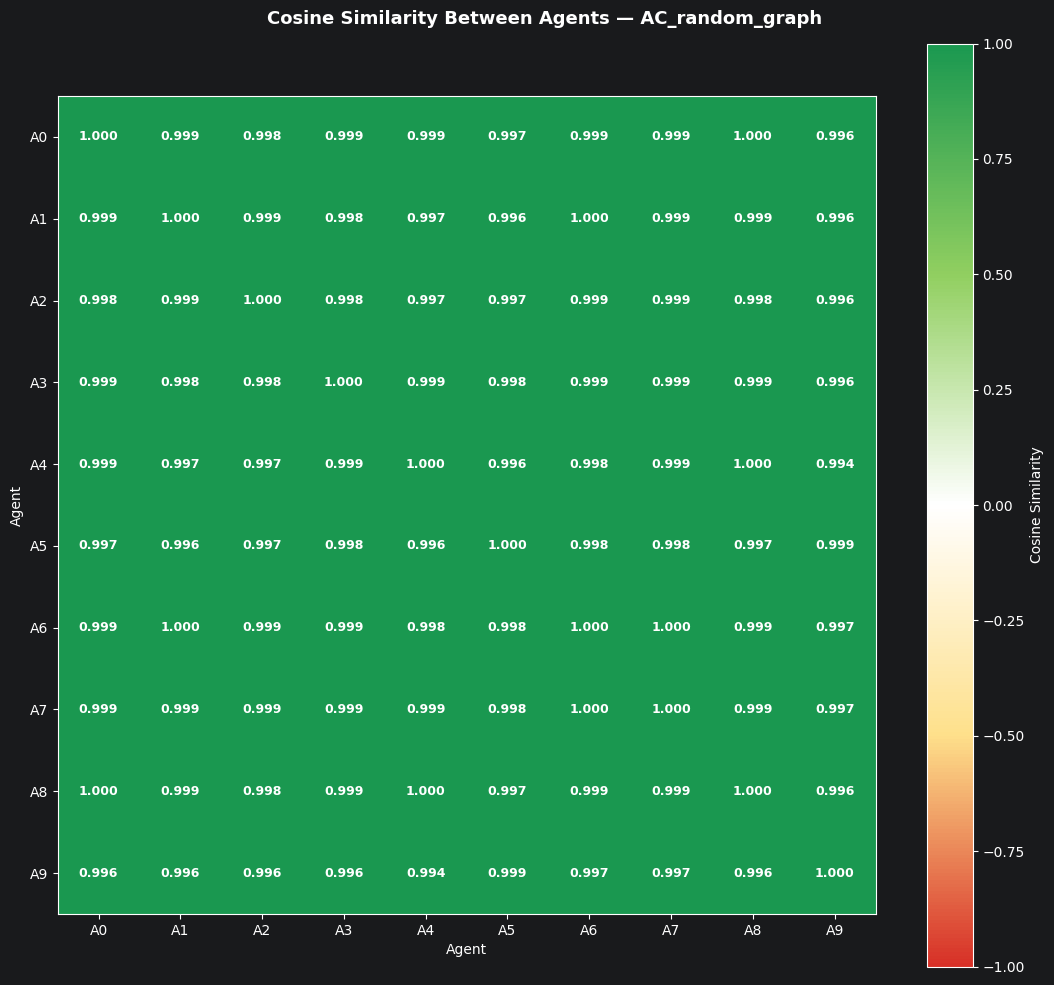

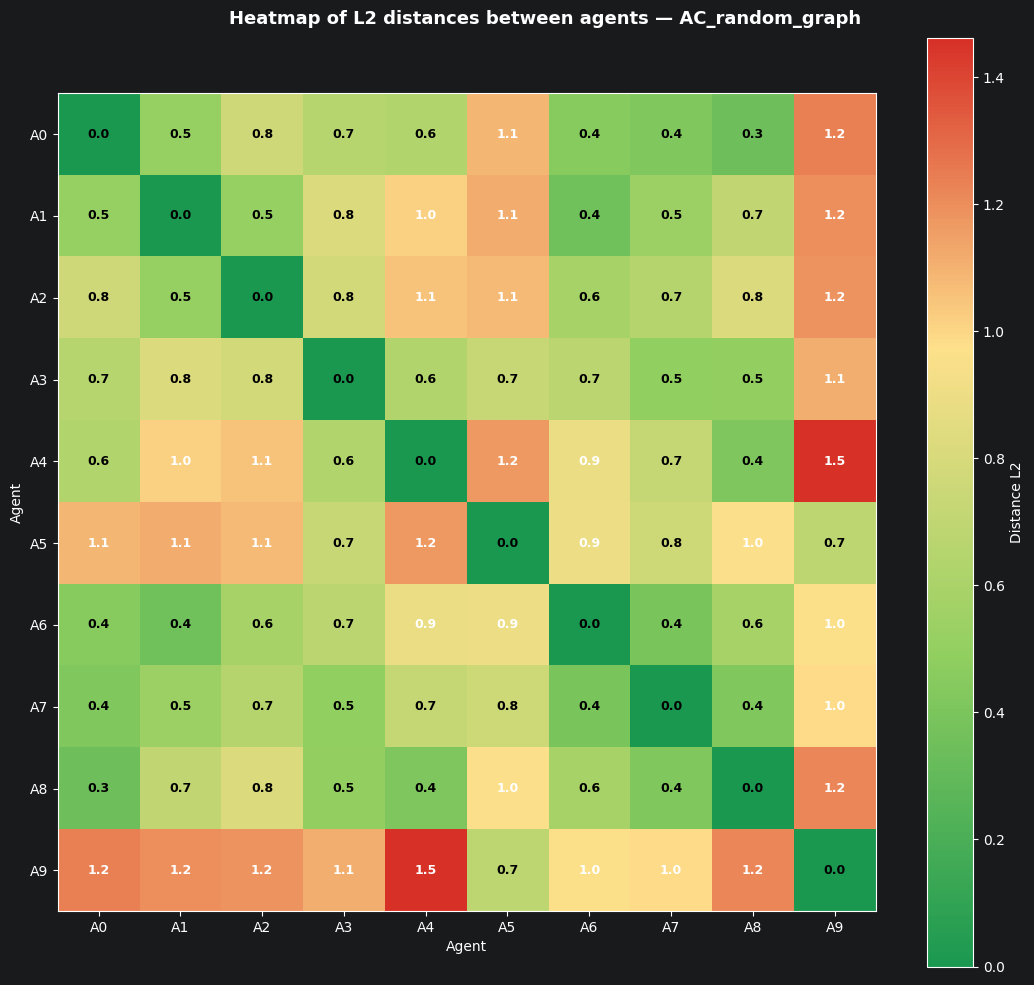

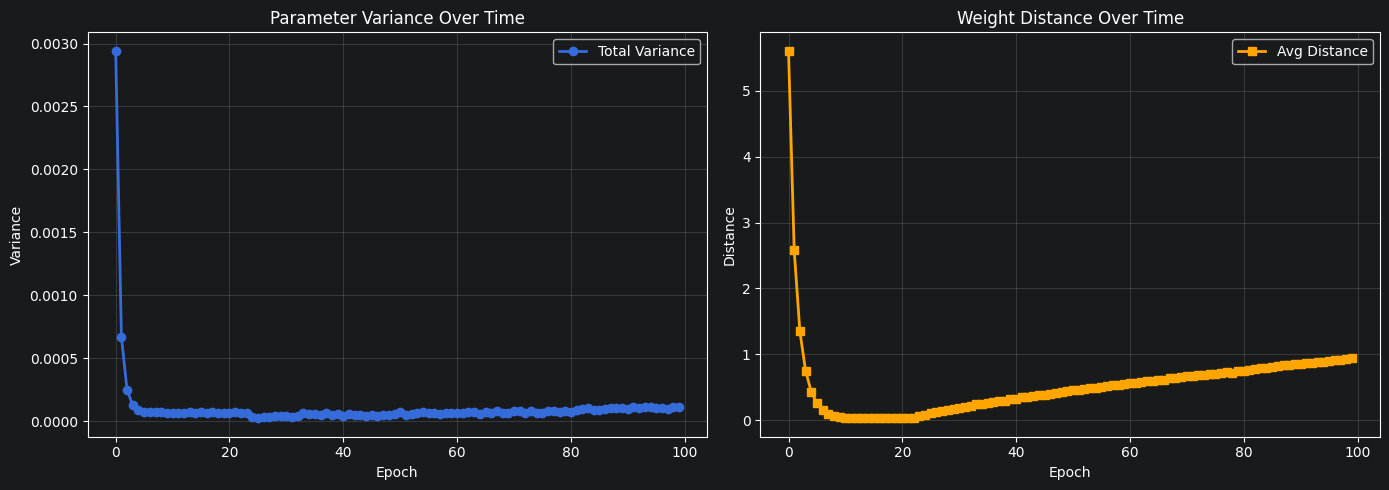

In [32]:
from metrics.metrics import plot_all_agent_node_weight_metric

for result in results:

    print(result)
    result.comm_cost.summary()
    plot_cosine_similarity(result)
    plot_distance_heatmap(result.agent_list, result.method_name)

    #plot_all_agent_node_weight_metric(result.agent_list)

    result.metrics.plot_history()

In [ ]:
def Average_consensus_fully_connected_graph_k(agent_list, graph, k, epoch, num_epochs, comm_cost=None):

    graph = NetworkTopology.fully_connected_graph(len(agent_list))

    Average_consensus_algorithm_K(
        agent_list,
        graph,
        K=k,
        comm_cost=comm_cost
    )


def Average_consensus_cycle_graph_k(
        agent_list, graph, k, epoch, num_epochs, comm_cost=None):

    graph = NetworkTopology.cycle_graph(len(agent_list))

    Average_consensus_algorithm_K(
        agent_list,
        graph,
        K=k,
        comm_cost=comm_cost
    )


def Average_consensus_star_graph_k(agent_list, graph, k, epoch, num_epochs, comm_cost=None):

    graph = NetworkTopology.star_graph(len(agent_list))

    Average_consensus_algorithm_K(
        agent_list,
        graph,
        K=k,
        comm_cost=comm_cost
    )


def Average_consensus_random_graph_k(agent_list, graph, k, epoch, num_epochs, comm_cost=None):

    Average_consensus_algorithm_K(
        agent_list,
        graph,
        K=k,
        comm_cost=comm_cost
    )


# ──────────────────────────────────────────────────────────────
# Dictionnaire des méthodes à comparer
# ──────────────────────────────────────────────────────────────

COMMUNICATION_METHODS = {

    "AC_fully_connected_graph":
        Average_consensus_fully_connected_graph_k,

    "AC_cycle_graph":
        Average_consensus_cycle_graph_k,

    "AC_star_graph":
        Average_consensus_star_graph_k,

    "AC_random_graph":
        Average_consensus_random_graph_k,
}


# Device configuration
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

agent_list = generate_agent(BATCH_SIZE, N_AGENT, DEVICE)

results, comparator = benchmark_sequential(
    communication_methods=COMMUNICATION_METHODS,
    num_epochs=NUM_EPOCHES,
    graph=random_graph,
    k=k,
    BATCH_SIZE=BATCH_SIZE,
    N_AGENT=N_AGENT,
    DEVICE=DEVICE,
)

0
Train size: 50000, Splits: [5555, 5555, 5555, 5555, 5555, 5555, 5555, 5555, 5555, 5555], Sum: 55550

  RUN — méthode : AC_fully_connected_graph
0
Train size: 50000, Splits: [5555, 5555, 5555, 5555, 5555, 5555, 5555, 5555, 5555, 5555], Sum: 55550
  [Epoch 1/100] threads started …
Agent 7 start
Agent 1 start
Agent 0 start
Agent 2 start
Agent 9 start
Agent 8 start
Agent 4 start
Agent 5 start
Agent 6 start
Agent 3 start
Model7 - Acc:13.72 % - Loss:2.2949920525550844 %
Model1 - Acc:10.32 % - Loss:2.302775861740112 %
Model0 - Acc:12.08 % - Loss:2.2983043789863586 %
Model2 - Acc:10.32 % - Loss:2.301000598907471 %
Model9 - Acc:9.62 % - Loss:2.3027791504859922 %
Model8 - Acc:12.66 % - Loss:2.298806032180786 %
Model4 - Acc:12.02 % - Loss:2.2953106899261475 %
Model5 - Acc:10.6 % - Loss:2.3012682538032534 %
Model6 - Acc:11.04 % - Loss:2.30386212015152 %
Model3 - Acc:11.0 % - Loss:2.301617757797241 %
[DEBUG] set_epoch_messages called → 450 messages
    → avrg distance after iteration 1: 0.000000


Exception ignored while calling deallocator <function _MultiProcessingDataLoaderIter.__del__ at 0x000002951C6F64B0>:
Traceback (most recent call last):
  File "C:\Users\flofl\PycharmProjects\IA_A_à_Z\.venv\Lib\site-packages\torch\utils\data\dataloader.py", line 1709, in __del__
    self._shutdown_workers()
  File "C:\Users\flofl\PycharmProjects\IA_A_à_Z\.venv\Lib\site-packages\torch\utils\data\dataloader.py", line 1667, in _shutdown_workers
    if self._persistent_workers or self._workers_status[worker_id]:
AttributeError: '_MultiProcessingDataLoaderIter' object has no attribute '_workers_status'


Erreur agent 0 : [Errno 22] Invalid argument
Agent 8 start
Agent 1 start
Agent 7 start
Agent 2 start
Agent 9 start
Agent 4 start
Agent 5 start
Agent 3 start
Agent 6 start
Model8 - Acc:9.72 % - Loss:2.3028712606430055 %
Model1 - Acc:10.54 % - Loss:2.3026899738311766 %
Model2 - Acc:10.66 % - Loss:2.30243413734436 %
Model7 - Acc:9.88 % - Loss:2.302732171535492 %
Model9 - Acc:10.38 % - Loss:2.3024951586723326 %
Model4 - Acc:9.6 % - Loss:2.3027294778823855 %
Model5 - Acc:10.14 % - Loss:2.3028029775619507 %
Model3 - Acc:9.88 % - Loss:2.302737842082977 %
Model6 - Acc:10.04 % - Loss:2.302850564479828 %
[DEBUG] set_epoch_messages called → 450 messages
    → avrg distance after iteration 1: 0.000000
    → avrg distance after iteration 2: 0.000000
    → avrg distance after iteration 3: 0.000000
    → avrg distance after iteration 4: 0.000000
    → avrg distance after iteration 5: 0.000000
[DEBUG] _resolve_n_messages → _epoch_n_messages = 450
[DEBUG] _record epoch=2 → n_messages=450
  [Epoch 3/100

Exception ignored while calling deallocator <function _MultiProcessingDataLoaderIter.__del__ at 0x000002951C6F64B0>:
Traceback (most recent call last):
  File "C:\Users\flofl\PycharmProjects\IA_A_à_Z\.venv\Lib\site-packages\torch\utils\data\dataloader.py", line 1709, in __del__
    self._shutdown_workers()
  File "C:\Users\flofl\PycharmProjects\IA_A_à_Z\.venv\Lib\site-packages\torch\utils\data\dataloader.py", line 1667, in _shutdown_workers
    if self._persistent_workers or self._workers_status[worker_id]:
AttributeError: '_MultiProcessingDataLoaderIter' object has no attribute '_workers_status'


Erreur agent 1 : [Errno 22] Invalid argument
Agent 6 start
Agent 0 start
Agent 7 start
Agent 5 start
Agent 8 start
Agent 3 start
Agent 4 start
Agent 9 start
Agent 2 start
Model6 - Acc:10.08 % - Loss:2.3023164825439455 %
Model0 - Acc:10.0 % - Loss:2.3024827075004577 %
Model7 - Acc:10.46 % - Loss:2.3022311835289 %
Model8 - Acc:10.98 % - Loss:2.3024038786888124 %
Model3 - Acc:10.28 % - Loss:2.3022098989486692 %
Model4 - Acc:10.92 % - Loss:2.3022602849006653 %
Model9 - Acc:11.3 % - Loss:2.302129741191864 %
Model2 - Acc:10.8 % - Loss:2.3021153869628908 %
Model5 - Acc:10.2 % - Loss:2.3024763231277467 %
[DEBUG] set_epoch_messages called → 450 messages
    → avrg distance after iteration 1: 0.000000
    → avrg distance after iteration 2: 0.000000
    → avrg distance after iteration 3: 0.000000
    → avrg distance after iteration 4: 0.000000
    → avrg distance after iteration 5: 0.000000
[DEBUG] _resolve_n_messages → _epoch_n_messages = 450
[DEBUG] _record epoch=25 → n_messages=450
  [Epoch 26

...

Erreur agent 3 : [Errno 22] Invalid argument
Agent 0 start
Agent 9 start
Agent 2 start
Agent 8 start
Agent 1 start
Agent 4 start
Agent 6 start
Agent 7 start
Agent 5 start
Model9 - Acc:33.46 % - Loss:1.7425430283546448 %
Model0 - Acc:32.74 % - Loss:1.7534347009658813 %
Model2 - Acc:32.96 % - Loss:1.7507693374156952 %
Model1 - Acc:33.9 % - Loss:1.754845232963562 %
Model4 - Acc:32.04 % - Loss:1.755991639137268 %
Model7 - Acc:33.52 % - Loss:1.7438887910842895 %
Model6 - Acc:32.38 % - Loss:1.7897522404193877 %
Model8 - Acc:33.44 % - Loss:1.7640164988040925 %
Model5 - Acc:32.78 % - Loss:1.7601408030986785 %
[DEBUG] set_epoch_messages called → 450 messages
    → avrg distance after iteration 1: 0.000000
    → avrg distance after iteration 2: 0.000000
    → avrg distance after iteration 3: 0.000000
    → avrg distance after iteration 4: 0.000000
    → avrg distance after iteration 5: 0.000000
[DEBUG] _resolve_n_messages → _epoch_n_messages = 450
[DEBUG] _record epoch=44 → n_messages=450
  [Epo

Exception ignored while calling deallocator <function _MultiProcessingDataLoaderIter.__del__ at 0x000002951C6F64B0>:
Traceback (most recent call last):
  File "C:\Users\flofl\PycharmProjects\IA_A_à_Z\.venv\Lib\site-packages\torch\utils\data\dataloader.py", line 1709, in __del__
    self._shutdown_workers()
  File "C:\Users\flofl\PycharmProjects\IA_A_à_Z\.venv\Lib\site-packages\torch\utils\data\dataloader.py", line 1667, in _shutdown_workers
    if self._persistent_workers or self._workers_status[worker_id]:
AttributeError: '_MultiProcessingDataLoaderIter' object has no attribute '_workers_status'


Erreur agent 7 : [Errno 22] Invalid argument
Agent 3 start
Agent 9 start
Agent 8 start
Agent 1 start
Agent 5 start
Agent 2 start
Agent 0 start
Agent 4 start
Agent 6 start
Model3 - Acc:47.44 % - Loss:1.420225175857544 %
Model9 - Acc:49.94 % - Loss:1.3754380108118058 %
Model1 - Acc:46.76 % - Loss:1.4233411165475844 %
Model5 - Acc:49.6 % - Loss:1.3909861946105957 %
Model2 - Acc:48.32 % - Loss:1.3890036952495575 %
Model4 - Acc:48.66 % - Loss:1.378056864142418 %
Model8 - Acc:49.6 % - Loss:1.3970286033153534 %
Model6 - Acc:48.3 % - Loss:1.4139821509122847 %
Model0 - Acc:48.78 % - Loss:1.3937609555721282 %
[DEBUG] set_epoch_messages called → 450 messages
    → avrg distance after iteration 1: 0.000001
    → avrg distance after iteration 2: 0.000000
    → avrg distance after iteration 3: 0.000000
    → avrg distance after iteration 4: 0.000000
    → avrg distance after iteration 5: 0.000000
[DEBUG] _resolve_n_messages → _epoch_n_messages = 450
[DEBUG] _record epoch=63 → n_messages=450
  [Epoch

Exception ignored while calling deallocator <function _MultiProcessingDataLoaderIter.__del__ at 0x000002951C6F64B0>:
Traceback (most recent call last):
  File "C:\Users\flofl\PycharmProjects\IA_A_à_Z\.venv\Lib\site-packages\torch\utils\data\dataloader.py", line 1709, in __del__
    self._shutdown_workers()
  File "C:\Users\flofl\PycharmProjects\IA_A_à_Z\.venv\Lib\site-packages\torch\utils\data\dataloader.py", line 1667, in _shutdown_workers
    if self._persistent_workers or self._workers_status[worker_id]:
AttributeError: '_MultiProcessingDataLoaderIter' object has no attribute '_workers_status'


Erreur agent 7 : [Errno 22] Invalid argument
Agent 2 start
Agent 0 start
Agent 1 start
Agent 9 start
Agent 3 start
Agent 5 start
Agent 6 start
Agent 4 start
Model2 - Acc:63.0 % - Loss:1.0322692916989327 %
Model0 - Acc:62.8 % - Loss:1.037080150157213 %
Model1 - Acc:62.12 % - Loss:1.0475043799877166 %
Model9 - Acc:63.94 % - Loss:1.0157527329921723 %
Model3 - Acc:62.9 % - Loss:1.064642676115036 %
Model5 - Acc:63.66 % - Loss:1.0353259934782981 %
Model4 - Acc:63.1 % - Loss:1.024368825018406 %
Model6 - Acc:62.18 % - Loss:1.073168871164322 %


In [ ]:
comparator.rank()

In [ ]:
plot_cumulative_times(results)
plot_epoch_times(results)

In [ ]:
comparator.plot_comparison()

In [ ]:
print_benchmark_summary(results)

In [ ]:
plot_all_benchmark_metrics(results)

In [ ]:
plot_average_distance(results)

In [ ]:
for result in results:
    print(f"\n── {result.method_name} ──")
    print(result)
    result.comm_cost.summary()

    plot_cosine_similarity(result)
    plot_distance_heatmap(result.agent_list, result.method_name)
    plot_all_agent_node_weight_metric(result.agent_list)

    result.metrics.plot_history()

In [ ]:
def Sequential_AC_fully_connected_graph(
        agent_list, graph, k, epoch, num_epochs, comm_cost=None):

    graph = NetworkTopology.fully_connected_graph(len(agent_list))

    Sequential_AC(
        agent_list,
        graph,
        comm_cost=comm_cost
    )


def Sequential_AC_cycle_graph(
        agent_list, graph, k, epoch, num_epochs, comm_cost=None):

    graph = NetworkTopology.cycle_graph(len(agent_list))

    Sequential_AC(
        agent_list,
        graph,
        comm_cost=comm_cost
    )


def Sequential_AC_star_graph(agent_list, graph, k, epoch, num_epochs, comm_cost=None):

    graph = NetworkTopology.star_graph(len(agent_list))

    Sequential_AC(
        agent_list,
        graph,
        comm_cost=comm_cost
    )


def Sequential_AC_random_graph(agent_list, graph, k, epoch, num_epochs, comm_cost=None):

    Sequential_AC(
        agent_list,
        graph,
        comm_cost=comm_cost
    )


# ──────────────────────────────────────────────────────────────
# Dictionnaire des méthodes à comparer
# ──────────────────────────────────────────────────────────────

COMMUNICATION_METHODS = {

    "Sequential_AC_connected_graph":
        Sequential_AC_fully_connected_graph,

    "Sequential_AC_cycle_graph":
        Sequential_AC_cycle_graph,

    "Sequential_AC_star_graph":
        Sequential_AC_star_graph,

    "Sequential_AC_random_graph":
        Sequential_AC_random_graph,
}

results, comparator = benchmark_sequential(
    communication_methods=COMMUNICATION_METHODS,
    num_epochs=NUM_EPOCHES,
    graph=random_graph,
    k=k,
    BATCH_SIZE=BATCH_SIZE,
    N_AGENT=N_AGENT,
    DEVICE=DEVICE,
)


In [ ]:
comparator.rank()

In [ ]:
plot_cumulative_times(results)
plot_epoch_times(results)

In [ ]:
comparator.plot_comparison()

In [ ]:
print_benchmark_summary(results)

In [ ]:
plot_all_benchmark_metrics(results)

In [ ]:

plot_average_distance(results)

In [ ]:
for result in results:
    print(f"\n── {result.method_name} ──")
    print(result)
    result.comm_cost.summary()

    plot_cosine_similarity(result)
    plot_distance_heatmap(result.agent_list, result.method_name)
    plot_all_agent_node_weight_metric(result.agent_list)

    result.metrics.plot_history()

In [ ]:
def Average_consensus_fully_connected_graph_k(
        agent_list, graph, k, epoch, num_epochs, comm_cost=None):

    graph = NetworkTopology.fully_connected_graph(len(agent_list))

    Average_consensus_algorithm_K(
        agent_list,
        graph,
        K=k,
        comm_cost=comm_cost
    )


def Average_consensus_cycle_graph_k(
        agent_list, graph, k, epoch, num_epochs, comm_cost=None):

    graph = NetworkTopology.cycle_graph(len(agent_list))

    Average_consensus_algorithm_K(
        agent_list,
        graph,
        K=k,
        comm_cost=comm_cost
    )


def Average_consensus_star_graph_k(
        agent_list, graph, k, epoch, num_epochs, comm_cost=None):

    graph = NetworkTopology.star_graph(len(agent_list))

    Average_consensus_algorithm_K(
        agent_list,
        graph,
        K=k,
        comm_cost=comm_cost
    )


def Average_consensus_random_graph_k(
        agent_list, graph, k, epoch, num_epochs, comm_cost=None):


    Average_consensus_algorithm_K(
        agent_list,
        graph,
        K=k,
        comm_cost=comm_cost
    )


# ──────────────────────────────────────────────────────────────
# Dictionnaire des méthodes à comparer
# ──────────────────────────────────────────────────────────────

COMMUNICATION_METHODS = {

    "AC_fully_connected_graph":
        Average_consensus_fully_connected_graph_k,

    "AC_cycle_graph":
        Average_consensus_cycle_graph_k,

    "AC_star_graph":
        Average_consensus_star_graph_k,

    "AC_random_graph":
        Average_consensus_random_graph_k,
}


# Device configuration
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

agent_list = generate_agent(BATCH_SIZE, N_AGENT, DEVICE)

results, comparator = benchmark_sequential(
    communication_methods=COMMUNICATION_METHODS,
    num_epochs=NUM_EPOCHES,
    graph=random_graph,
    k=k,
    BATCH_SIZE=BATCH_SIZE,
    N_AGENT=N_AGENT,
    DEVICE=DEVICE,
)

print_benchmark_summary(results)
comparator.rank()
plot_all_benchmark_metrics(results)
plot_average_distance(results)
plot_cumulative_times(results)
plot_epoch_times(results)

for result in results:
    print(result)
    plot_cosine_similarity(result)
    plot_distance_heatmap(result.agent_list, result.method_name)
    plot_all_agent_node_weight_metric(result.agent_list)

    result.metrics.plot_history()
    result.comm_cost.summary()

In [ ]:
def Average_consensus_fully_connected_graph_k(
        agent_list, graph, k, epoch, num_epochs, comm_cost=None):

    graph = NetworkTopology.fully_connected_graph(len(agent_list))

    exact_diffusion_consensus(
        agent_list,
        graph,
        K=k,
        comm_cost=comm_cost
    )


def Average_consensus_cycle_graph_k(
        agent_list, graph, k, epoch, num_epochs, comm_cost=None):

    graph = NetworkTopology.cycle_graph(len(agent_list))

    Average_consensus_algorithm_K(
        agent_list,
        graph,
        K=k,
        comm_cost=comm_cost
    )


def Average_consensus_star_graph_k(
        agent_list, graph, k, epoch, num_epochs, comm_cost=None):

    graph = NetworkTopology.star_graph(len(agent_list))

    Average_consensus_algorithm_K(
        agent_list,
        graph,
        K=k,
        comm_cost=comm_cost
    )


def Average_consensus_random_graph_k(
        agent_list, graph, k, epoch, num_epochs, comm_cost=None):


    Average_consensus_algorithm_K(
        agent_list,
        graph,
        K=k,
        comm_cost=comm_cost
    )


# ──────────────────────────────────────────────────────────────
# Dictionnaire des méthodes à comparer
# ──────────────────────────────────────────────────────────────

COMMUNICATION_METHODS = {

    "AC_fully_connected_graph":
        Average_consensus_fully_connected_graph_k,

    "AC_cycle_graph":
        Average_consensus_cycle_graph_k,

    "AC_star_graph":
        Average_consensus_star_graph_k,

    "AC_random_graph":
        Average_consensus_random_graph_k,
}


# Device configuration
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

agent_list = generate_agent(BATCH_SIZE, N_AGENT, DEVICE)

results, comparator = benchmark_sequential(
    communication_methods=COMMUNICATION_METHODS,
    num_epochs=NUM_EPOCHES,
    graph=random_graph,
    k=k,
    BATCH_SIZE=BATCH_SIZE,
    N_AGENT=N_AGENT,
    DEVICE=DEVICE,
)

print_benchmark_summary(results)
comparator.rank()
plot_all_benchmark_metrics(results)
plot_average_distance(results)
plot_cumulative_times(results)
plot_epoch_times(results)

for result in results:
    print(result)
    plot_cosine_similarity(result)
    plot_distance_heatmap(result.agent_list, result.method_name)
    plot_all_agent_node_weight_metric(result.agent_list)

    result.metrics.plot_history()
    result.comm_cost.summary()